In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as inter
import pandas as pd
import seaborn as sns

# Simulação do Tubo de Raios Catódicos (TRC)

## Objetivo
Simular a trajetória do elétron sob campo elétrico obtido via FEMM e comparar com dados experimentais.

## Estrutura do notebook

1. Definição dos parâmetros
2. Importação do campo elétrico
3. Aproximação do modelo físico
4. Construção da função de campo
5. Validação do campo
6. Simulação da trajetória
7. Ajuste aos dados experimentais
8. Trajetória $(x,y)$ do elétron e impacto na tela

## Metodologia
- Campo elétrico obtido por simulação numérica
- Integração da equação de movimento

## 1. Parâmetros físicos e geométricos
Definição das constantes físicas e parâmetros da simulação.

In [ ]:
#@title Parâmetros físicos e geométricos

# ================= CONSTANTES =================
m = 9.11e-31   # massa do elétron (kg)
q = 1.6e-19    # carga (valor absoluto)

# ================= TENSÕES =================
Vacfixo = np.array([500,600,700,800,900,1000,1100,1200,1400])
Vp = np.arange(1.0, 30.5, 0.5)

# ================= GEOMETRIA =================
x_ini = -0.035
x_tela = 0.2187
dx = 0.0005

# ================= FEMM =================
Vpsim = 1.0

## 2. Leitura dos dados do FEMM
Carregamento do campo elétrico exportado.

In [ ]:
#@title Leitura do CSV do FEMM

# ================= LEITURA =================
df = pd.read_csv("electric_field_data.csv")

# ================= SELEÇÃO DO CORTE =================
y_ref = df.loc[df["y"] > 0, "y"].min()

df_slice = df[np.isclose(df["y"], y_ref)].copy()
df_slice = df_slice.sort_values("x")

# ================= CONVERSÕES =================
xsim = df_slice["x"].values / 1000.0
Esim = df_slice["Ey"].values

print("Corte em y =", y_ref)

Corte em torno de y = 3.3
Valores únicos de y selecionados: [3.3333]


## 3. Aproximação do campo elétrico

Explicação

### 3.1 Modelo Adotado

O campo elétrico obtido via FEMM é uma função bidimensional:

$$
E_y = E_y(x, y)
$$

ou seja, sua intensidade depende tanto da posição ao longo do eixo \($x$\) quanto da altura \($y$\) entre as placas.

No entanto, neste modelo foi adotada a seguinte aproximação:

$$
E_y(x, y) \approx E_y(x, y_{\text{ref}})
$$

onde \($y_{\text{ref}}$\) é um valor próximo de zero, correspondente à região central entre as placas.

Na prática, isso significa que:

- foi selecionado um corte horizontal do campo elétrico no plano \($y \approx 0$\)
- a partir desse corte, construiu-se uma função unidimensional \($E_y(x)$\)
- essa função é então utilizada para calcular a trajetória do elétron

 .


### 3.2 Justificativa de aproximação

Essa simplificação é válida sob as seguintes condições:

- o feixe de elétrons permanece próximo da região central entre as placas
- a variação do campo elétrico com \($y$\) é pequena nessa região
- a deflexão do feixe dentro da região de campo é relativamente pequena

Nessas condições, o campo elétrico pode ser bem aproximado por seu valor ao longo do eixo central.

Essa abordagem reduz significativamente a complexidade do modelo, permitindo:

- uma implementação mais simples
- maior estabilidade numérica
- interpretação mais direta dos resultados

.

### 3.3 Limitações do modelo

A principal limitação dessa aproximação é que ela ignora a dependência do campo elétrico com a altura \($y$\).

Na prática, isso significa que:

- a trajetória do elétron é calculada usando sempre o campo correspondente ao eixo central
- efeitos de borda e não-uniformidades do campo em \($y$\) não são considerados
- a deflexão pode ser subestimada ou superestimada dependendo da geometria

.

### 3.5 Conclusão

O modelo adotado representa um compromisso entre simplicidade e fidelidade física.

A aproximação \($E_y(x, y) \approx E_y(x, 0)$\) é suficiente para capturar o comportamento principal da deflexão do feixe, sendo adequada para análise inicial e fins didáticos.

A validade dessa aproximação pode ser avaliada comparando os resultados da simulação com os dados experimentais obtidos no tubo de raios catódicos.

## 4. Construção da função α(x)
Normalização do campo elétrico obtido no FEMM.

In [ ]:
#@title Construção da função alfa(x)

# ================= INTERPOLAÇÃO =================
alfafunc = inter.interp1d(
    xsim,
    Esim / Vpsim,
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

print("Campo máximo:", np.max(np.abs(Esim)), "V/m")

Campo máximo: 454.5454 V/m


## 5. Visualização do campo elétrico
Verificação do perfil de campo ao longo do eixo x.

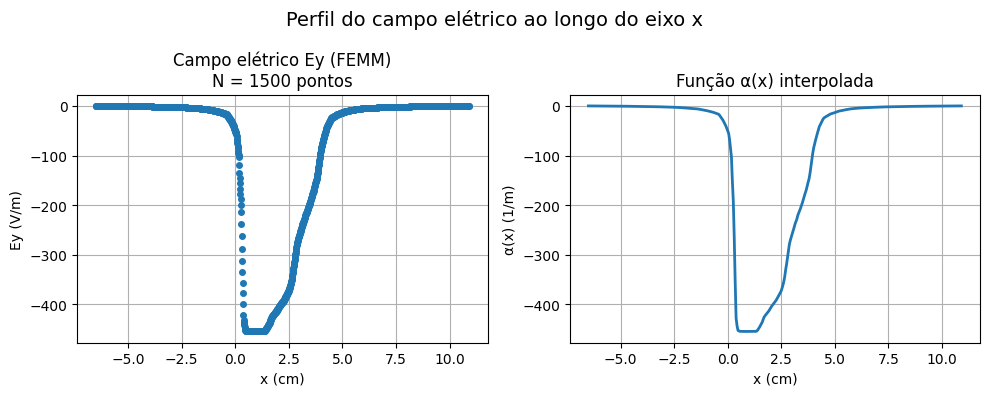

In [ ]:
#@title Visualização do campo

# ================= EIXO PARA INTERPOLAÇÃO =================
# Cria 400 pontos igualmente espaçados no domínio de x (em metros)
# Usado para visualizar a função contínua α(x)
x_plot = np.linspace(min(xsim), max(xsim), 400)

# ================= CONVERSÃO DE UNIDADES =================
# Converter de metros para centímetros para exibição
xsim_cm = xsim * 100
x_plot_cm = x_plot * 100

# ================= PLOT =================
plt.figure(figsize=(10,4))

# -------- Campo (dados discretos do FEMM) --------
plt.subplot(1,2,1)
plt.plot(
    xsim_cm, Esim,
    marker='o',
    linestyle='None',
    markersize=4
)
plt.xlabel("x (cm)")
plt.ylabel("Ey (V/m)")
plt.title(f"Campo elétrico Ey (FEMM)\nN = {len(xsim)} pontos")
plt.grid()

# -------- Alfa (função contínua interpolada) --------
plt.subplot(1,2,2)
plt.plot(
    x_plot_cm,
    alfafunc(x_plot),
    linestyle='-',
    linewidth=2
)
plt.xlabel("x (cm)")
plt.ylabel("α(x) (1/m)")
plt.title("Função α(x) interpolada")
plt.grid()

# -------- Título geral --------
plt.suptitle("Perfil do campo elétrico ao longo do eixo x", fontsize=14)

plt.tight_layout()
plt.show()

## 6. Simulação da trajetória do elétron
Integração da equação de movimento sob o campo elétrico.

In [ ]:
#@title Simulação da trajetória

x = np.arange(x_ini, x_tela + dx, dx)

yVp = np.zeros((len(Vacfixo), len(Vp)))

# ================= LOOP PRINCIPAL =================
for k, Vac in enumerate(Vacfixo):

    dt = dx * np.sqrt(m / (2 * q * Vac))

    for j, Vp_val in enumerate(Vp):

        y = 0.0
        vy = 0.0

        for x_val in x:
            E_val = float(alfafunc(x_val)) * Vp_val
            ay = -q * E_val / m  # elétron

            y += vy*dt + 0.5*ay*dt**2
            vy += ay*dt

        # yVp[k, j] armazena diretamente a posição do elétron na tela
        yVp[k, j] = y

print("Ordem de grandeza de y:", np.max(np.abs(yVp)))

Ordem de grandeza de y: 0.08432810071489369


## 7. Ajuste linear e comparação com experimento

Visualização da simulação e dos dados experimentais.

### 7.1 Aplicação do MMQ (com ODR) e visualização final.


Tentando carregar dados experimentais...
Formato esperado do CSV: Vp, y, dVp, dy

⚠️ CSV de dados experimentais não encontrado.
→ Apenas a simulação será exibida.


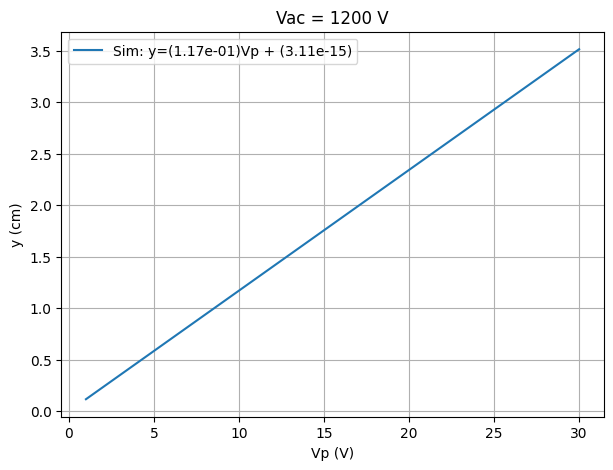


=== MMQ (Simulação) ===
Modelo: y = a·Vp + b

a = 1.1712e-01 cm/V
b = 3.1118e-15 cm
R² = 1.000000

(Dados experimentais não utilizados nesta execução)


In [ ]:
#@title Gráfico y vs Vp com MMQ (simulação + experimental opcional)

# ================= IMPORTS =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ODR = Orthogonal Distance Regression (considera incertezas em x e y)
# Aqui usamos como um "MMQ generalizado"
from scipy import odr as mmq

# ================= CONFIGURAÇÕES =================
Vacfix = 1200
csv_exp = "dados_experimentais.csv"
tamanho_ponto = 40  # tamanho visual dos pontos

# ================= SIMULAÇÃO =================
idx = np.where(Vacfixo == Vacfix)[0][0]
y_vals = yVp[idx] * 100  # m → cm

# -------- MMQ SIMULAÇÃO --------
coef_sim = np.polyfit(Vp, y_vals, 1)
a_sim, b_sim = coef_sim
y_fit_sim = a_sim * Vp + b_sim

# métricas
res_sim = y_vals - y_fit_sim
ss_res_sim = np.sum(res_sim**2)
ss_tot_sim = np.sum((y_vals - np.mean(y_vals))**2)
r2_sim = 1 - ss_res_sim / ss_tot_sim

# ================= PLOT =================
plt.figure(figsize=(7,5))

plt.plot(
    Vp, y_fit_sim, '-',
    label=f"Sim: y=({a_sim:.2e})Vp + ({b_sim:.2e})"
)

# ================= DADOS EXPERIMENTAIS =================
print("\nTentando carregar dados experimentais...")
print("Formato esperado do CSV: Vp, y, dVp, dy")

dados_experimentais_carregados = False

try:
    # -------- LEITURA DO CSV --------
    df_exp = pd.read_csv(csv_exp)

    # -------- VALIDAÇÃO --------
    colunas = ["Vp", "y", "dVp", "dy"]
    for c in colunas:
        if c not in df_exp.columns:
            raise ValueError(f"Coluna '{c}' não encontrada")

    # -------- EXTRAÇÃO --------
    Vp_exp = df_exp["Vp"].values
    y_exp = df_exp["y"].values
    dVp = df_exp["dVp"].values
    dy = df_exp["dy"].values

    print("✔ Dados experimentais carregados com sucesso.")

    # -------- PLOT EXPERIMENTAL --------
    plt.errorbar(
        Vp_exp, y_exp,
        xerr=dVp, yerr=dy,
        fmt='o',
        markersize=tamanho_ponto/5,
        capsize=3,
        label='Experimental'
    )

    # ================= MMQ (ODR) =================

    def modelo(B, x):
        return B[0]*x + B[1]

    modelo_mmq = mmq.Model(modelo)

    dados_mmq = mmq.RealData(
        Vp_exp,
        y_exp,
        sx=dVp,
        sy=dy
    )

    # chute inicial melhorado
    ajuste = mmq.ODR(dados_mmq, modelo_mmq, beta0=[a_sim, b_sim])
    resultado = ajuste.run()

    a_exp, b_exp = resultado.beta
    erro_a_exp, erro_b_exp = resultado.sd_beta

    # linha ajustada
    Vp_lin = np.linspace(min(Vp_exp), max(Vp_exp), 200)
    y_fit_exp = a_exp*Vp_lin + b_exp

    plt.plot(
        Vp_lin, y_fit_exp, '--',
        label=f"Exp: y=({a_exp:.2e})Vp + ({b_exp:.2e})"
    )

    # métricas (aproximação em y)
    y_fit_exp_data = a_exp*Vp_exp + b_exp
    res_exp = y_exp - y_fit_exp_data

    ss_res_exp = np.sum(res_exp**2)
    ss_tot_exp = np.sum((y_exp - np.mean(y_exp))**2)
    r2_exp = 1 - ss_res_exp / ss_tot_exp  # estimativa

    dados_experimentais_carregados = True

except FileNotFoundError:
    print("\n⚠️ CSV de dados experimentais não encontrado.")
    print("→ Apenas a simulação será exibida.")

except pd.errors.EmptyDataError:
    print("\n⚠️ O arquivo CSV está vazio.")
    print("→ Apenas a simulação será exibida.")

except ValueError as e:
    print("\n⚠️ Problema nas colunas do CSV:")
    print("→", e)
    print("→ Esperado: Vp, y, dVp, dy")

except Exception as e:
    print("\n⚠️ Erro ao processar os dados experimentais:")
    print("→", e)

# ================= FORMATAÇÃO =================
plt.title(f'Vac = {Vacfix} V')
plt.xlabel('Vp (V)')
plt.ylabel('y (cm)')
plt.grid()
plt.legend()
plt.show()

# ================= RESULTADOS =================

# -------- SIMULAÇÃO --------
print("\n=== MMQ (Simulação) ===")
print("Modelo: y = a·Vp + b\n")
print(f"a = {a_sim:.4e} cm/V")
print(f"b = {b_sim:.4e} cm")
print(f"R² = {r2_sim:.6f}")

# -------- EXPERIMENTAL --------
if dados_experimentais_carregados:
    print("\n=== MMQ (Experimental) ===")
    print("Modelo: y = a·Vp + b\n")

    print(f"a = ({a_exp:.4e} ± {erro_a_exp:.2e}) cm/V")
    print(f"b = ({b_exp:.4e} ± {erro_b_exp:.2e}) cm")

    print("\nQualidade do ajuste:")
    print(f"R² = {r2_exp:.6f}")
    print(f"Resíduo quadrático = {ss_res_exp:.4e}")

else:
    print("\n(Dados experimentais não utilizados nesta execução)")

### 7.2 Conclusões

- O modelo reproduz o comportamento linear observado
- O campo obtido no FEMM é consistente com a deflexão
- A inclusão de incertezas melhora o ajuste experimental

## 8. Trajetória do elétron e impacto na tela

Visualização $(x,y)$ do elétron e marcações na tela dos dados experimentais.

⚠️ Usando valores padrão de Vac da simulação.


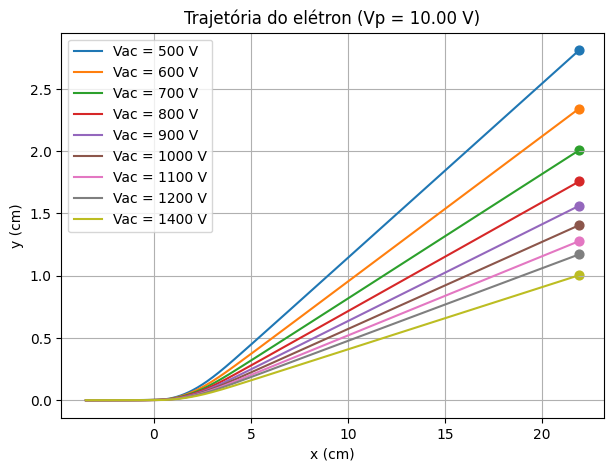


=== Posição na tela (simulação) ===
Vac = 500 V → y = 2.811 cm
Vac = 600 V → y = 2.342 cm
Vac = 700 V → y = 2.008 cm
Vac = 800 V → y = 1.757 cm
Vac = 900 V → y = 1.562 cm
Vac = 1000 V → y = 1.405 cm
Vac = 1100 V → y = 1.278 cm
Vac = 1200 V → y = 1.171 cm
Vac = 1400 V → y = 1.004 cm


In [ ]:
#@title Trajetória do elétron + impacto na tela

# ================= CONFIGURAÇÕES =================
Vptraj = 10.0
csv_exp = "dados_tela.csv"  # opcional
          # Arquivo CSV opcional com dados experimentais
          # Formato esperado (com cabeçalho):
          #
          # Vac  → tensão de aceleração (V)
          # y    → posição do feixe na tela (cm)
          # dVac → incerteza em Vac (V)
          # dy   → incerteza em y (cm)
          #
          # Exemplo:
          # Vac,y,dVac,dy
          # 600,2.8,5,0.1
          # 800,2.0,5,0.1
          #
          # Observação:
          # - As colunas devem ter exatamente esses nomes
          # - As unidades devem ser mantidas conforme indicado

# ================= ÍNDICE DO Vp =================
idx_vp = np.argmin(np.abs(Vp - Vptraj))

# ================= CONVERSÃO DE UNIDADES =================
x_cm = x * 100  # m → cm

# ================= VAC UTILIZADOS =================
Vac_usados = Vacfixo.copy()

# tentar usar Vac dos alunos
try:
    df_exp = pd.read_csv(csv_exp)
    if "Vac" in df_exp.columns:
        Vac_usados = df_exp["Vac"].values
        print("✔ Usando valores de Vac dos dados experimentais.")
except:
    print("⚠️ Usando valores padrão de Vac da simulação.")

# ================= PLOT =================
plt.figure(figsize=(7,5))

y_tela_lista = []

for Vac_val in Vac_usados:

    # índice mais próximo no array da simulação
    idx_vac = np.argmin(np.abs(Vacfixo - Vac_val))

    # recalcular trajetória (ou usar já calculada se tiver y completo)
    vy = 0.0
    y_pos = 0.0

    y_traj = []

    for xi in x:
        if xi < np.max(xsim):
            E = alfafunc(xi) * Vptraj
        else:
            E = 0.0

        dt = dx * np.sqrt(m / (2 * q * Vac_val))
        ay = -q * E / m

        y_pos = y_pos + vy*dt + 0.5*ay*dt**2
        vy = vy + ay*dt

        y_traj.append(y_pos)

    y_traj = np.array(y_traj) * 100  # m → cm

    # salvar ponto final
    y_tela = y_traj[-1]
    y_tela_lista.append(y_tela)

    # plot trajetória
    plt.plot(x_cm, y_traj, label=f"Vac = {Vac_val:.0f} V")

    # ponto na tela
    plt.scatter(x_cm[-1], y_tela, s=40)

# ================= FORMATAÇÃO =================
plt.title(f"Trajetória do elétron (Vp = {Vptraj:.2f} V)")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.grid()
plt.legend()

plt.show()

# ================= VALORES NA TELA =================
print("\n=== Posição na tela (simulação) ===")
for Vac_val, y_val in zip(Vac_usados, y_tela_lista):
    print(f"Vac = {Vac_val:.0f} V → y = {y_val:.3f} cm")

### ...em teste


Tentando carregar dados experimentais (formato esperado: Vac, y, dVac, dy)...

⚠️ Dados experimentais não disponíveis.
→ Apenas a simulação será exibida.
→ Detalhe: [Errno 2] No such file or directory: 'dados_tela.csv'


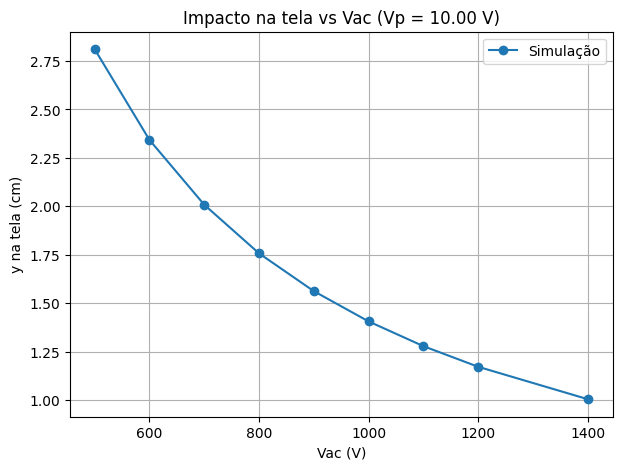


Intervalo da simulação:
y mínimo = 1.004 cm
y máximo = 2.811 cm


In [ ]:
# @title TESTE, em desenvolvimento
# ==========================================================
# BLOCO: Impacto na tela — Simulação vs Experimento
# ----------------------------------------------------------
# Autor: [Seu Nome]
# Data: [DD/MM/AAAA]
# Versão: 0.1
#
# Objetivo:
# Comparar a posição de impacto na tela obtida por simulação
# com dados experimentais, incluindo incertezas.
#
# Entradas:
# - Vptraj: tensão de placa selecionada (Vp)
# - Vacfixo: vetor de tensões de aceleração
# - yVp: matriz de trajetórias simuladas
# - csv_exp: arquivo com dados experimentais
#
# Saídas:
# - Gráfico comparativo (simulação vs experimento)
# - Intervalo de valores simulados na tela
#
# Observações:
# - Executar após a simulação completa da trajetória
# - Se não houver dados experimentais, plota apenas simulação
# ==========================================================

# ================= CONFIGURAÇÕES =================
Vptraj = 10.0                 # valor de Vp usado pelo aluno
csv_exp = "dados_tela.csv"   # arquivo experimental (opcional)
tamanho_ponto = 50

# ================= ÍNDICE DO Vp =================
idx_vp = np.argmin(np.abs(Vp - Vptraj))

# ================= EXTRAÇÃO DO PONTO NA TELA =================
# último ponto da trajetória em x
y_tela_sim = yVp[:, idx_vp] * 100  # converter m → cm

# ================= PLOT =================
plt.figure(figsize=(7,5))

# -------- SIMULAÇÃO --------
plt.plot(
    Vacfixo,
    y_tela_sim,
    '-o',
    label='Simulação'
)

# ================= DADOS EXPERIMENTAIS =================
print("\nTentando carregar dados experimentais (formato esperado: Vac, y, dVac, dy)...")

try:
    df_exp = pd.read_csv(csv_exp)

    # -------- VALIDAÇÃO --------
    colunas = ["Vac", "y", "dVac", "dy"]
    for c in colunas:
        if c not in df_exp.columns:
            raise ValueError(f"Coluna '{c}' não encontrada")

    # -------- EXTRAÇÃO --------
    Vac_exp = df_exp["Vac"].values
    y_exp = df_exp["y"].values
    dVac = df_exp["dVac"].values
    dy = df_exp["dy"].values

    print("✔ Dados experimentais carregados.")

    # -------- PLOT EXPERIMENTAL --------
    plt.errorbar(
        Vac_exp, y_exp,
        xerr=dVac, yerr=dy,
        fmt='o',
        markersize=tamanho_ponto/5,
        capsize=3,
        label='Experimental'
    )

except Exception as e:
    print("\n⚠️ Dados experimentais não disponíveis.")
    print("→ Apenas a simulação será exibida.")
    print("→ Detalhe:", e)

# ================= FORMATAÇÃO =================
plt.title(f"Impacto na tela vs Vac (Vp = {Vptraj:.2f} V)")
plt.xlabel("Vac (V)")
plt.ylabel("y na tela (cm)")
plt.grid()
plt.legend()

plt.show()

# ================= INFORMAÇÃO ADICIONAL =================
print("\nIntervalo da simulação:")
print(f"y mínimo = {np.min(y_tela_sim):.3f} cm")
print(f"y máximo = {np.max(y_tela_sim):.3f} cm")